# Grid-search sensitivity analysis — interactive plotter

Same logic as `experiments/mib/visualization/plotters/grid_search_sensitivity.py`,
split into editable cells.

- Cell 2 = data loading (run once per kernel)
- Cell 3 = visual config (colors, font sizes, gaps)
- Cell 4 = `_plot_block` — per-subplot logic
- Cell 5 = `make_figure` — overall layout
- Cell 6 = render + display
- Cell 7 = save to PNG (optional)

Recommended iteration: tweak Cell 3 / Cell 4 / Cell 5 → re-run Cell 6.

Source root is controlled by `GRID_DIR_NAME`:
- `'grid_search'` (default)  → EAP+Scaling sweep
- `'frozen_grid_search'`    → EAP+FrozenNorm+Scaling sweep

In [86]:
# ── Cell 1: imports ─────────────────────────────────────────────
import os, csv
from collections import defaultdict

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
%matplotlib inline

In [87]:
# ── Cell 2: data loading ────────────────────────────────────────
PATHS = ('q', 'k', 'v', 'gate', 'up')
WEIGHT_VALUES = (0.0, 0.05, 0.1, 0.2, 0.5, 1.0, 1.5, 3.0)

GRID_DIR_NAME = os.environ.get('GRID_DIR_NAME', 'grid_search')
GRID_DIR = os.path.abspath(os.path.join(
    os.getcwd().split('experiments/mib')[0],
    'experiments/mib', GRID_DIR_NAME,
))
GRID_REPORT_CSV = os.path.join(GRID_DIR, 'report.csv')
PLOT_OUT = os.path.join(GRID_DIR, 'plots', 'sensitivity_analysis.png')

print('CSV:    ', GRID_REPORT_CSV)
print('output: ', PLOT_OUT)

def load_summaries(csv_path=GRID_REPORT_CSV):
    """Returns {(model, task): {'per_axis': {axis: [(value, cpr), ...]}, 'baseline_cpr': float|None}}."""
    rows = list(csv.DictReader(open(csv_path)))
    raw = defaultdict(list)
    for r in rows:
        if r['cpr'] in ('-', ''):
            continue
        raw[(r['model'], r['task'])].append(r)

    out = {}
    for mt, block in raw.items():
        baseline = next((r for r in block if all(r[p] == '1.0' for p in PATHS)), None)
        per_axis = {}
        for ax in PATHS:
            ax_rows = [r for r in block if all(r[p] == '1.0' for p in PATHS if p != ax)]
            ax_rows.sort(key=lambda r: float(r[ax]))
            per_axis[ax] = [(float(r[ax]), float(r['cpr'])) for r in ax_rows]
        out[mt] = {
            'per_axis':     per_axis,
            'baseline_cpr': float(baseline['cpr']) if baseline is not None else None,
        }
    return out

summaries = load_summaries()
for mt, s in summaries.items():
    print(f"{mt[0]}/{mt[1]}: baseline CPR={s['baseline_cpr']}")

CSV:     /home/dacslab/djk/lasse-circuit/circuit_discovery/experiments/mib/grid_search/report.csv
output:  /home/dacslab/djk/lasse-circuit/circuit_discovery/experiments/mib/grid_search/plots/sensitivity_analysis.png
gpt2/ioi: baseline CPR=1.238
qwen2.5/ioi: baseline CPR=0.2661
qwen2.5/mcqa: baseline CPR=1.0069
gemma2/ioi: baseline CPR=0.8853
gemma2/mcqa: baseline CPR=1.2242


In [88]:
# ── Cell 3: visual config (tweak here) ──────────────────────────
AXIS_COLORS = {
    'q':    '#1f77b4',
    'k':    '#ff7f0e',
    'v':    '#2ca02c',
    'gate': '#d62728',
    'up':   '#9467bd',
}

# Display names for the legend (keys must match AXIS_COLORS / PATHS).
AXIS_DISPLAY = {
    'q':    'Query',
    'k':    'Key',
    'v':    'Value',
    'gate': 'Gate',
    'up':   'Up',
}

# Layout: rows = task (ioi top, mcqa bottom), GridSpec(2 x 6) so each subplot spans 2 cols.
LAYOUT_GS = {
    ('gpt2',    'ioi'):  (0, slice(0, 2)),
    ('qwen2.5', 'ioi'):  (0, slice(2, 4)),
    ('gemma2',  'ioi'):  (0, slice(4, 6)),
    ('qwen2.5', 'mcqa'): (1, slice(1, 3)),
    ('gemma2',  'mcqa'): (1, slice(3, 5)),
}

# ─ font sizes
FONT_AXLABEL = 14
FONT_AXTITLE = 13
FONT_TICK    = 11
FONT_LEGEND  = 14

# ─ figure / gridspec
FIGSIZE      = (18, 9)
GS_HSPACE    = 0.36   # row spacing
GS_WSPACE    = 0.55   # col spacing
GS_TOP       = 0.96
GS_BOTTOM    = 0.18
GS_LEFT      = 0.06
GS_RIGHT     = 0.98

# ─ legend bbox (x, y, w, h) — stretched to full width via mode='expand'
LEGEND_BBOX  = (0.03, 0.02, 0.94, 0.13)
LEGEND_NCOL  = 4
LEGEND_HANDLETEXTPAD = 0.5
LEGEND_COLUMNSPACING = 1.0
LEGEND_LABELSPACING  = 0.2

In [89]:
# ── Cell 4: per-subplot plotter ─────────────────────────────────
def plot_block(ax, model, task, summary):
    per_axis = summary['per_axis']
    base_cpr = summary['baseline_cpr']

    val_to_idx = {v: i for i, v in enumerate(WEIGHT_VALUES)}
    baseline_idx = val_to_idx.get(1.0)

    if base_cpr is not None:
        ax.axhline(base_cpr, color='0.4', linestyle='--', linewidth=1.4, zorder=1)

    for axis_name in PATHS:
        pts = per_axis.get(axis_name, [])
        if not pts: continue
        xs = [val_to_idx.get(round(v, 4)) for v, _ in pts]
        ys = [c for _, c in pts]
        xy = sorted([(x, y) for x, y in zip(xs, ys) if x is not None])
        if not xy: continue
        xs_, ys_ = zip(*xy)
        max_idx = max(range(len(ys_)), key=lambda i: ys_[i])
        ax.plot(xs_, ys_, color=AXIS_COLORS[axis_name],
                linewidth=1.8, marker='o', markersize=5, zorder=2)
        ax.plot([xs_[max_idx]], [ys_[max_idx]],
                color=AXIS_COLORS[axis_name],
                marker='*', markersize=11, linestyle='None', zorder=3)

    ax.set_xlabel('Scale parameter value', fontsize=FONT_AXLABEL)
    ax.set_ylabel('CPR Score', fontsize=FONT_AXLABEL)
    ax.set_title(f'Dataset: {task.upper()}, Model: {model.upper()}', fontsize=FONT_AXTITLE)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(list(range(len(WEIGHT_VALUES))))
    ax.set_xticklabels([str(v) for v in WEIGHT_VALUES], fontsize=FONT_TICK)
    ax.tick_params(axis='y', labelsize=FONT_TICK)
    if baseline_idx is not None:
        ax.axvline(baseline_idx, color='0.7', linewidth=0.6, linestyle=':', zorder=0)


def legend_handles():
    h = [Line2D([0], [0], color='0.4', linestyle='--', linewidth=1.4,
                label='baseline (uniform 1.0)')]
    for ax in PATHS:
        h.append(Line2D([0], [0], color=AXIS_COLORS[ax], linewidth=1.8,
                        marker='o', markersize=5, label=f'{AXIS_DISPLAY[ax]} scale parameter'))
    h.append(Line2D([0], [0], color='black', linestyle='None',
                    marker='*', markersize=11, label='Best value (max CPR)'))
    return h

In [90]:
# ── Cell 5: assemble the figure ─────────────────────────────────
def make_figure(summaries):
    fig = plt.figure(figsize=FIGSIZE)
    gs = fig.add_gridspec(2, 6,
                          hspace=GS_HSPACE, wspace=GS_WSPACE,
                          left=GS_LEFT, right=GS_RIGHT,
                          top=GS_TOP, bottom=GS_BOTTOM)

    for mt, (row, col_slice) in LAYOUT_GS.items():
        ax = fig.add_subplot(gs[row, col_slice])
        if mt not in summaries:
            ax.set_axis_off()
            ax.text(0.5, 0.5, f'{mt[0]}/{mt[1]}\n(no data)',
                    ha='center', va='center', transform=ax.transAxes)
            continue
        plot_block(ax, mt[0], mt[1], summaries[mt])

    fig.legend(
        handles=legend_handles(),
        loc='lower center',
        ncol=LEGEND_NCOL,
        fontsize=FONT_LEGEND,
        frameon=True,
        bbox_to_anchor=LEGEND_BBOX,
        mode='expand',
        borderaxespad=0.3,
        handletextpad=LEGEND_HANDLETEXTPAD,
        columnspacing=LEGEND_COLUMNSPACING,
        labelspacing=LEGEND_LABELSPACING,
    )
    return fig

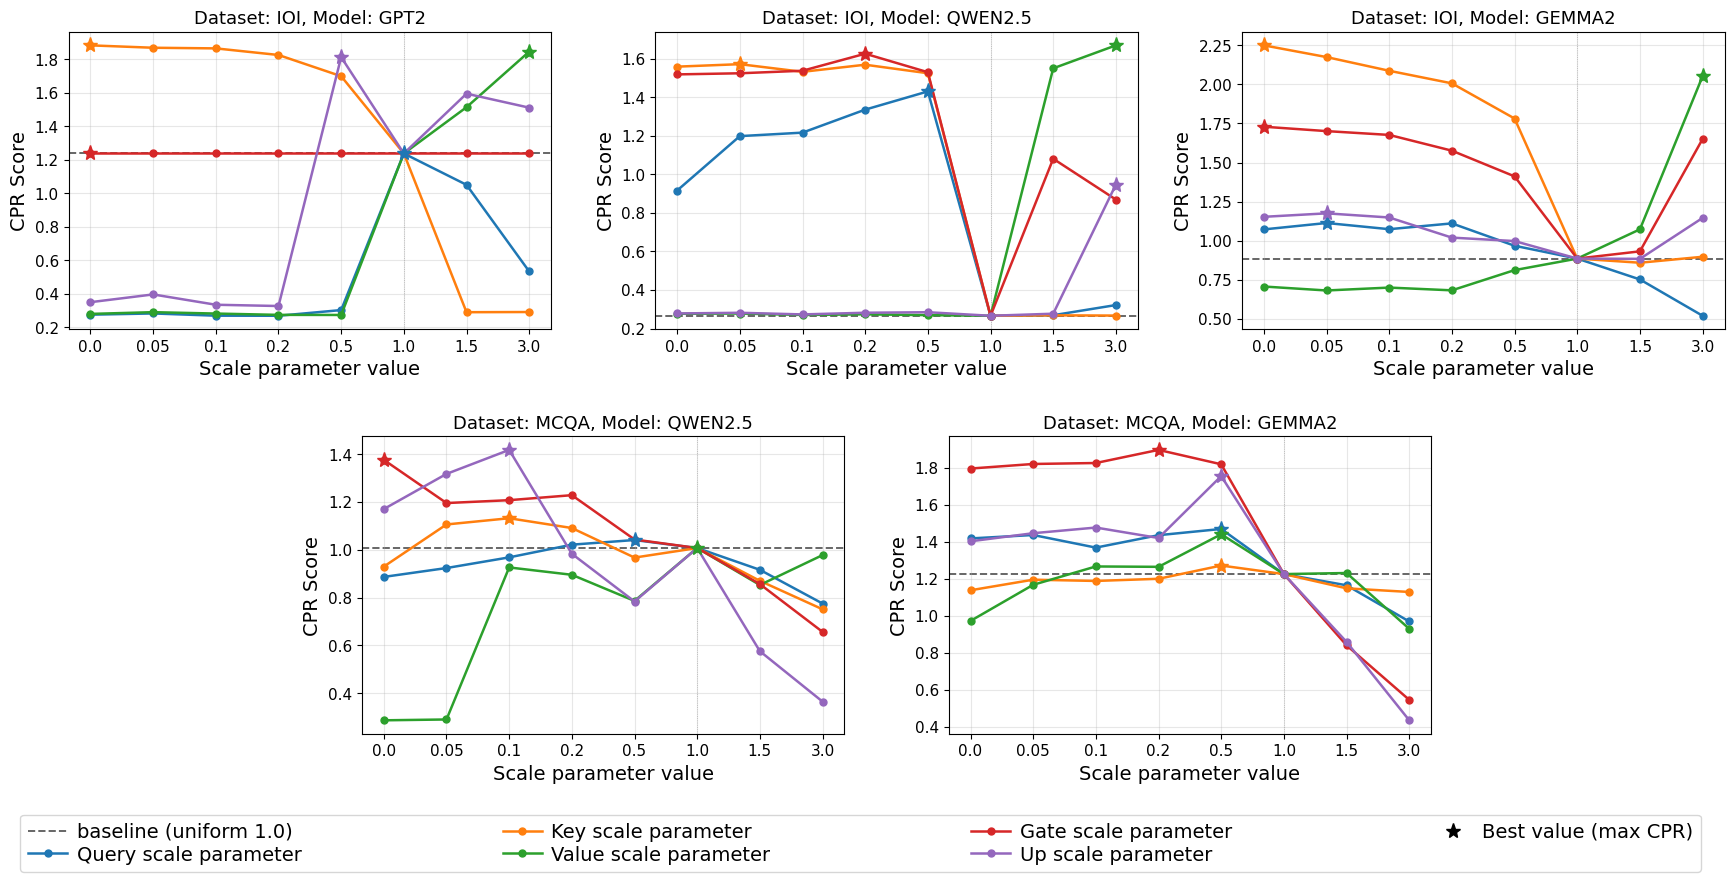

In [91]:
# ── Cell 6: render & display ────────────────────────────────────
fig = make_figure(summaries)
plt.show()

In [92]:
# ── Cell 7: save to PNG (optional) ──────────────────────────────
os.makedirs(os.path.dirname(PLOT_OUT), exist_ok=True)
fig.savefig(PLOT_OUT, dpi=150, bbox_inches='tight')
print(f'saved → {PLOT_OUT}')

saved → /home/dacslab/djk/lasse-circuit/circuit_discovery/experiments/mib/grid_search/plots/sensitivity_analysis.png
